# Synthetic Mobility Data — Evaluation

**Generation-free.** Reads the artefacts written by Script A (synthetic CSVs, per-user MIA tables, user splits) and computes every evaluation metric, organised by research question.

- **RQ1 — Utility:** can the models reproduce OD-level mobility patterns?
- **RQ2 — Privacy:** do the models leak via record reproduction and membership inference?
- **RQ3 — Activity groups:** do higher-activity users face greater leakage?

**Design.** Per-seed metrics are written to `EVAL_LOG` (utility + record-level privacy). The MIA headline (RQ2) and all of RQ3 are computed by **pooling the per-user `__mia_results.csv` tables across seeds**, with a user-level bootstrap CI. Utility is summarised as **mean ± std over seeds** (seeds are replicates); MIA is **pooled** (per-seed eval sets are too small to resolve). Bootstrap is the copy-based **control**, not a competitor.

## 0 · Setup

In [1]:
%pip install h3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.4 MB/s eta 0:00:00


In [2]:
# Colab only — mount Drive and cd to the project root if needed
from google.colab import drive
drive.mount('/content/drive')
# %cd /content/drive/MyDrive/<your_project_path>

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/UPF_Thesis/v4

/content/drive/MyDrive/UPF_Thesis/v4


In [4]:
import importlib, src.evaluation.v4_metrics
importlib.reload(src.evaluation.v4_metrics)        # pick up edits without restarting
import src.evaluation.v4_metrics as m
print('metrics:', [f for f in dir(m) if f.endswith(('_jsd', '_metrics'))][:8])

metrics: ['_jsd', 'dcr_metrics', 'mia_score_metrics', 'nndr_metrics', 'od_flow_jsd', 'spatial_jsd', 'temporal_jsd']


In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score

from src.user_split import (
    load_and_filter_trip_data, get_main_training_users,
    get_users_by_split, get_user_trips,
)
from src.log_experiments import log_metrics
try:
    from IPython.display import display
except ImportError:
    display = print

## 1 · Config

In [6]:
SEEDS  = [111, 222, 333, 444, 555]
MODELS = ['VAE', 'WGAN_GP', 'Bootstrap']

DATA_PATH     = 'od_trips_20260410_input.csv'      # <-- adjust if needed
ARTIFACT_ROOT = Path('artifacts_v4')
SPLIT_DIR     = ARTIFACT_ROOT / 'splits'
EVAL_LOG      = 'outputs/eval_log_v4.json'
OUT_DIR       = Path('outputs/figures'); OUT_DIR.mkdir(parents=True, exist_ok=True)

OD_COLS     = [m.START_LAT, m.START_LON, m.END_LAT, m.END_LON]   # real column names
CORR_COLS   = ['duration_minutes', 'centroid_dist', *OD_COLS]
GROUP_ORDER = ['10-20', '21-63', '64+']            # <-- set to your actual group labels

FPR_TARGETS = (0.01, 0.05, 0.10)
N_BOOT      = 2000
COLOURS     = {'Bootstrap': '#d62728', 'VAE': '#1f77b4', 'WGAN_GP': '#2ca02c'}

## 2 · Helpers

In [7]:
def _haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dl   = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))



def add_speed_feature(df):
    # Recompute centroid_dist from coords so REAL and SYNTH share ONE definition
    # (fixes the real/synth schema mismatch), then derive speed.
    df = df.copy()
    df['centroid_dist'] = _haversine_m(df[m.START_LAT], df[m.START_LON],
                                       df[m.END_LAT], df[m.END_LON])
    with np.errstate(divide='ignore', invalid='ignore'):
        df['speed_kmh'] = (df['centroid_dist'] / 1000.0) / (df['duration_minutes'] / 60.0)
    df['speed_kmh'] = df['speed_kmh'].replace([np.inf, -np.inf], np.nan)
    return df


def build_train_holdout(df, user_summary):
    # train = what the main generator saw; holdout = eval_out users (never seen)
    train   = get_user_trips(df, get_main_training_users(user_summary))
    holdout = get_user_trips(df, get_users_by_split(user_summary, 'eval_out'))
    return train, holdout


def _json_safe(o):
    if isinstance(o, dict):          return {k: _json_safe(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_json_safe(v) for v in o]
    if isinstance(o, np.integer):    return int(o)
    if isinstance(o, (np.floating, float)):
        return None if (isinstance(o, float) and o != o) else float(o)
    if isinstance(o, np.ndarray):    return o.tolist()
    return o

In [8]:
def distribution_similarity(real_df, synth_df, cols=None):
    # Per-coordinate marginal fidelity, averaged across coordinates:
    #   mean_ks              max CDF gap (fragile on discretised marginals)
    #   mean_wasserstein_std scale-free Earth-Mover distance
    #   mean_std_ratio       synth spread / real spread
    cols = cols or OD_COLS
    ks, emd, sr = [], [], []
    for c in cols:
        r = pd.to_numeric(real_df[c], errors='coerce').dropna().to_numpy()
        s = pd.to_numeric(synth_df[c], errors='coerce').dropna().to_numpy()
        if len(r) < 2 or len(s) < 2:
            continue
        sd = r.std()
        ks.append(ks_2samp(r, s).statistic)
        emd.append(wasserstein_distance(r, s) / sd if sd > 0 else 0.0)
        sr.append(s.std() / sd if sd > 0 else np.nan)
    return {'mean_ks': float(np.mean(ks)),
            'mean_wasserstein_std': float(np.mean(emd)),
            'mean_std_ratio': float(np.nanmean(sr))}

## 3 · Per-seed evaluation  →  writes `EVAL_LOG`

In [9]:
def evaluate_one(model_name, seed, df):
    base = ARTIFACT_ROOT / model_name / f'{model_name.lower()}_seed{seed}'
    synth_path = Path(f'{base}.csv')
    if not synth_path.exists():
        print(f'  [skip] {synth_path} missing'); return None

    user_summary = pd.read_csv(SPLIT_DIR / f'user_summary_seed{seed}.csv')
    synth_df = add_speed_feature(pd.read_csv(synth_path))
    real_df  = add_speed_feature(df)
    train_df, holdout_df = build_train_holdout(df, user_summary)

    metrics = {}
    # ---- RQ1: utility / fidelity ----
    metrics.update(m.od_flow_jsd(real_df, synth_df, h3_res=6))
    metrics.update(m.spatial_jsd(real_df, synth_df, h3_res=7))
    if {'hour', 'start_time'} & set(synth_df.columns):
        metrics.update(m.temporal_jsd(real_df, synth_df))
    else:
        print('  [skip] temporal — no time column')
    metrics.update(m.correlation_diff(real_df, synth_df, CORR_COLS))
    metrics.update(m.tstr_destination(real_df, synth_df, random_state=seed))
    metrics.update(distribution_similarity(train_df, synth_df))

    # ---- RQ2: record-level privacy ----
    metrics.update(m.duplicate_rate(synth_df, train_df))            # near_copy / exact_match (works)
    metrics.update(m.dcr_metrics(synth_df, train_df, holdout_df))   # degenerate -> Limitations
    metrics.update(m.nndr_metrics(synth_df, train_df))              # degenerate -> Limitations

    # ---- RQ2: per-seed MIA scalars (the pooled headline is computed in §4) ----
    mia_path = Path(f'{base}__mia_results.csv')
    if mia_path.exists():
        metrics.update(m.mia_score_metrics(pd.read_csv(mia_path)))
    else:
        print(f'  [skip] MIA scoring — {mia_path} missing')

    # ---- per-group utility + distance-privacy (per-group MIA is pooled in §4) ----
    util_g = m.utility_by_group(real_df, synth_df, user_summary, h3_res=6)
    priv_g = m.distance_privacy_by_group(synth_df, train_df, holdout_df, user_summary)
    by_group = {}
    for _, r in util_g.iterrows():
        by_group.setdefault(r['activity_group'], {}).update(
            {f'util_{k}': v for k, v in r.items() if k != 'activity_group'})
    for _, r in priv_g.iterrows():
        by_group.setdefault(r['activity_group'], {}).update(
            {f'priv_{k}': v for k, v in r.items() if k != 'activity_group'})
    metrics['by_activity_group'] = by_group

    print(f"  od_flow_jsd={metrics.get('od_flow_jsd'):.4f}  "
          f"near_copy={metrics.get('near_copy_rate')}  MIA_AUC={metrics.get('mia_auc')}")
    log_metrics(seed=seed, model=f'{model_name}__eval', metrics=_json_safe(metrics),
                path=EVAL_LOG, notes='Script B clean: utility + record-privacy + per-seed MIA',
                overwrite=True)
    return metrics

In [10]:
df = load_and_filter_trip_data(DATA_PATH)
Path('outputs').mkdir(parents=True, exist_ok=True)
print('trips:', len(df), '| columns:', list(df.columns))

Removed rows: 30
Percent removed: 0.39
trips: 7739 | columns: ['trip_id', 'user_id', 'session_id', 'start_time', 'end_time', 'duration_minutes', 'start_hex', 'end_hex', 'n_points', 'inter_hex_num', 'avg_gps_splits', 'traj_start_lat', 'traj_start_lon', 'traj_end_lat', 'traj_end_lon', 'traj_dist_m', 'mode', 'start_centroid_lat', 'start_centroid_lon', 'end_centroid_lat', 'end_centroid_lon', 'centroid_dist', 'centroid_speed_kmh']


In [11]:
for seed in SEEDS:
    for model_name in MODELS:
        print(f'=== {model_name} | seed {seed} ===')
        evaluate_one(model_name, seed, df)
print('Done ->', EVAL_LOG)

=== VAE | seed 111 ===
  od_flow_jsd=0.4216  near_copy=0.009681678157547308  MIA_AUC=0.5063492063492063
Updating existing log row: seed=111, model=VAE__eval
⚠️ Overwriting metric for seed=111, model=VAE__eval: od_flow_jsd: 0.42161700398691043 -> 0.42161700398691043
⚠️ Overwriting metric for seed=111, model=VAE__eval: od_flow_js_distance: 0.6493204170414715 -> 0.6493204170414715
⚠️ Overwriting metric for seed=111, model=VAE__eval: od_flow_coverage: 0.4314759036144578 -> 0.4314759036144578
⚠️ Overwriting metric for seed=111, model=VAE__eval: n_real_od_pairs: 1328 -> 1328
⚠️ Overwriting metric for seed=111, model=VAE__eval: n_synth_od_pairs: 1966 -> 1966
⚠️ Overwriting metric for seed=111, model=VAE__eval: origin_cell_js_distance: 0.8413148785664388 -> 0.8413148785664388
⚠️ Overwriting metric for seed=111, model=VAE__eval: origin_cell_coverage: 0.38613861386138615 -> 0.38613861386138615
⚠️ Overwriting metric for seed=111, model=VAE__eval: dest_cell_js_distance: 0.8512350489149287 -> 0.851

## 4 · Aggregate loaders & stats

In [ ]:
def load_eval_log(path=EVAL_LOG):
    rows = []
    for r in json.loads(Path(path).read_text()):
        flat = {'model': r['model'].replace('__eval', ''), 'seed': r['seed']}
        flat.update({k: v for k, v in r.get('metrics', {}).items() if k != 'by_activity_group'})
        rows.append(flat)
    return pd.DataFrame(rows)

eval_df = load_eval_log()
print(eval_df.shape, '|', sorted(eval_df['model'].unique()))

(15, 35) | ['Bootstrap', 'VAE', 'WGAN_GP']


In [ ]:
def load_pooled_mia():
    # Concatenate per-user MIA tables across seeds/models. If a table lacks
    # activity_group, merge it from that seed's user_summary so RQ3 works
    # regardless of whether Script A saved the column.
    frames = []
    for model in MODELS:
        for seed in SEEDS:
            f = ARTIFACT_ROOT / model / f'{model.lower()}_seed{seed}__mia_results.csv'
            if not f.exists():
                print(f'  [skip] {f} missing'); continue
            d = pd.read_csv(f)
            d['model'], d['seed'] = model, seed
            if 'activity_group' not in d.columns:
                us = pd.read_csv(SPLIT_DIR / f'user_summary_seed{seed}.csv')
                d = d.merge(us[['user_id', 'activity_group']], on='user_id', how='left')
            frames.append(d)
    if not frames:
        raise FileNotFoundError('No __mia_results.csv found under ' + str(ARTIFACT_ROOT))
    pooled = pd.concat(frames, ignore_index=True)
    miss = {'user_id', 'ground_truth', 'membership_probability'} - set(pooled.columns)
    if miss:
        raise KeyError(f'mia_results missing columns: {miss}')
    if 'activity_group' in pooled and pooled['activity_group'].isna().any():
        print('  [warn] some users lack an activity_group after merge')

    pooled['activity_group'] = (
        pooled['activity_group']
        .astype(str)
        .str.replace('–', '-', regex=False)
        .str.strip())

    return pooled

pooled = load_pooled_mia()
print('pooled MIA:', len(pooled), 'rows |', pooled['user_id'].nunique(), 'unique users')

pooled MIA: 795 rows | 85 unique users


In [ ]:
def _mia_metrics(y, p, fpr_targets=FPR_TARGETS):
    out = {'auc': float(roc_auc_score(y, p))}
    fpr, tpr, _ = roc_curve(y, p)
    out['yeom_adv'] = float(np.max(tpr - fpr))
    for t in fpr_targets:
        out[f'tpr@{int(t * 100)}'] = float(np.interp(t, fpr, tpr))
    out['bal_acc'] = float(balanced_accuracy_score(y, (p >= 0.5).astype(int)))
    return out


def cluster_bootstrap(d, n_boot=N_BOOT, seed=0):
    # User-level (cluster) bootstrap: resample USERS, keep all their seed-rows.
    y = d['ground_truth'].to_numpy(); p = d['membership_probability'].to_numpy()
    users = d['user_id'].to_numpy()
    point = _mia_metrics(y, p)
    u2i = {u: np.where(users == u)[0] for u in np.unique(users)}
    uniq = np.array(list(u2i)); rng = np.random.default_rng(seed)
    boots = {k: [] for k in point}
    for _ in range(n_boot):
        idx = np.concatenate([u2i[u] for u in rng.choice(uniq, size=len(uniq), replace=True)])
        yy, pp = y[idx], p[idx]
        if len(np.unique(yy)) < 2:
            continue
        for k, v in _mia_metrics(yy, pp).items():
            boots[k].append(v)
    ci = {k: (float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5)))
          for k, b in boots.items() if b}
    return point, ci


def fmt(pt, ci, k):
    lo, hi = ci.get(k, (np.nan, np.nan))
    return f'{pt[k]:.3f} [{lo:.3f}, {hi:.3f}]'

## RQ1 · Utility / fidelity
Can the models reproduce OD-level mobility patterns? Seeds are replicates, so utility is **mean ± std across seeds**. Bootstrap is the copy-based **ceiling**, so the meaningful comparison is VAE vs WGAN-GP.

In [ ]:
rq1_cols = ['od_flow_jsd', 'od_flow_coverage', 'dest_cell_js_distance', 'hour_js_distance',
            'mean_wasserstein_std', 'mean_std_ratio', 'mean_ks', 'tstr_ratio']
rq1_cols = [c for c in rq1_cols if c in eval_df.columns]
rq1 = eval_df.groupby('model')[rq1_cols].agg(['mean', 'std']).round(4).reindex(MODELS)
print('RQ1 utility — mean +/- std over seeds:'); display(rq1)
#rq1.to_csv(OUT_DIR / 'rq1_utility_summary.csv')

RQ1 utility — mean +/- std over seeds:


od_flow_jsd         od_flow_coverage         dest_cell_js_distance  \
                 mean     std             mean     std                  mean   
model                                                                          
VAE            0.4518  0.0375           0.4270  0.0176                0.8508   
WGAN_GP        0.4069  0.0451           0.3721  0.0133                0.8432   
Bootstrap      0.0995  0.0509           0.6735  0.0500                0.1590   

                  hour_js_distance         mean_wasserstein_std          \
              std             mean     std                 mean     std   
model                                                                     
VAE        0.0033           0.1540  0.0209               0.1667  0.0023   
WGAN_GP    0.0092           0.1487  0.0227               0.1204  0.0055   
Bootstrap  0.0659           0.0585  0.0244               0.0182  0.0037   

          mean_std_ratio         mean_ks         tstr_ratio          
                    mean     std    mean     std       mean     std  
model                                                                
VAE               0.8036  0.0111  0.1655  0.0125     0.2712  0.0448  
WGAN_GP           0.9083  0.0243  0.1568  0.0135     0.2510  0.0384  
Bootstrap         1.0075  0.0121  0.2188  0.0170     0.9875  0.0423

In [ ]:
rq1.T

model                          VAE  WGAN_GP  Bootstrap
od_flow_jsd           mean  0.4518   0.4069     0.0995
                      std   0.0375   0.0451     0.0509
od_flow_coverage      mean  0.4270   0.3721     0.6735
                      std   0.0176   0.0133     0.0500
dest_cell_js_distance mean  0.8508   0.8432     0.1590
                      std   0.0033   0.0092     0.0659
hour_js_distance      mean  0.1540   0.1487     0.0585
                      std   0.0209   0.0227     0.0244
mean_wasserstein_std  mean  0.1667   0.1204     0.0182
                      std   0.0023   0.0055     0.0037
mean_std_ratio        mean  0.8036   0.9083     1.0075
                      std   0.0111   0.0243     0.0121
mean_ks               mean  0.1655   0.1568     0.2188
                      std   0.0125   0.0135     0.0170
tstr_ratio            mean  0.2712   0.2510     0.9875
                      std   0.0448   0.0384     0.0423

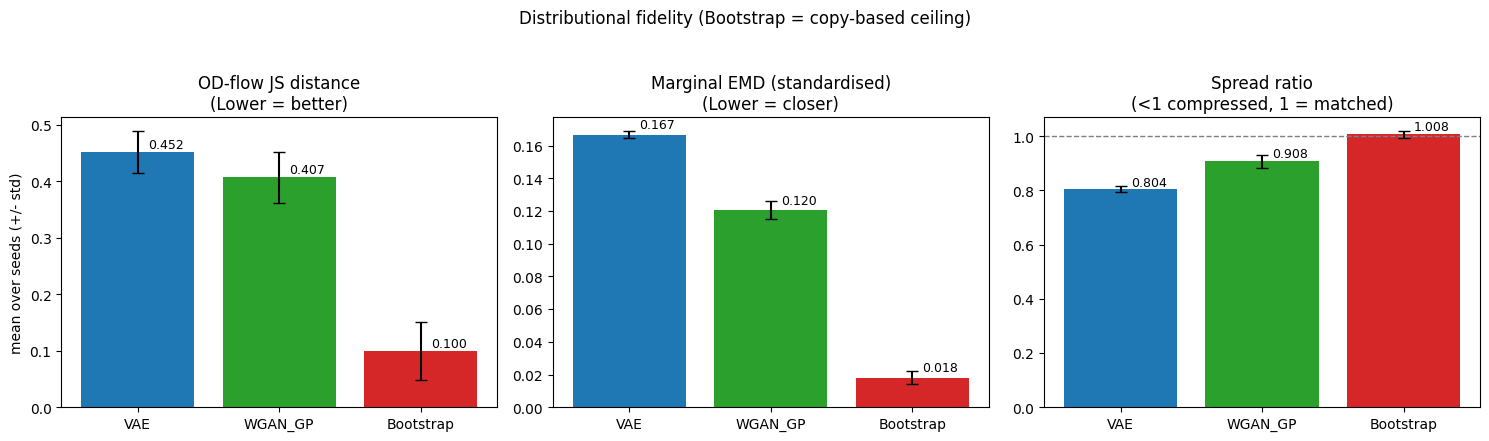

Note: mean_ks is in the table but de-emphasised — it is fragile on discretised marginals.


In [ ]:
specs = [('od_flow_jsd',          'OD-flow JS distance\n(Lower = better)',          None),
         ('mean_wasserstein_std', 'Marginal EMD (standardised)\n(Lower = closer)',  None),
         ('mean_std_ratio',       'Spread ratio\n(<1 compressed, 1 = matched)',      1.0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (key, title, ref) in zip(axes, specs):
    means = [rq1.loc[mdl, (key, 'mean')] for mdl in MODELS]
    stds  = [rq1.loc[mdl, (key, 'std')]  for mdl in MODELS]
    bars = ax.bar(MODELS, means, yerr=stds, capsize=4, color=[COLOURS[mdl] for mdl in MODELS])
    if ref is not None:
        ax.axhline(ref, ls='--', c='grey', lw=1)
    for b, v in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2 + 0.2, v+0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
axes[0].set_ylabel('mean over seeds (+/- std)')
plt.suptitle('Distributional fidelity (Bootstrap = copy-based ceiling)', y=1.04)
plt.tight_layout(); plt.savefig(OUT_DIR / 'rq1_fidelity.png', dpi=150, bbox_inches='tight'); plt.show()
print('Note: mean_ks is in the table but de-emphasised — it is fragile on discretised marginals.')

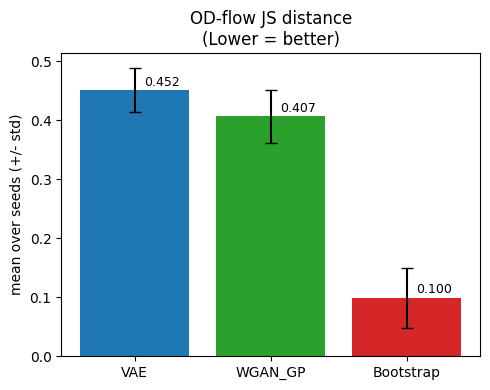

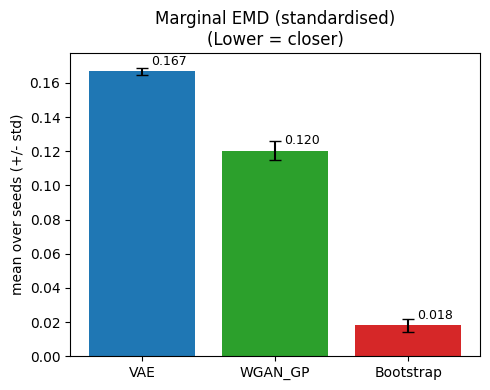

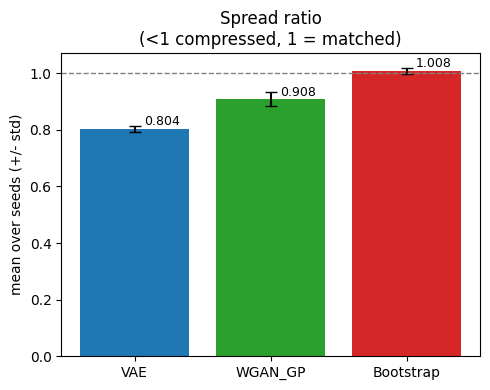

In [ ]:
for key, title, ref in specs:
    means = [rq1.loc[mdl, (key, 'mean')] for mdl in MODELS]
    stds  = [rq1.loc[mdl, (key, 'std')]  for mdl in MODELS]
    plt.figure(figsize=(5, 4))
    bars = plt.bar(MODELS, means, yerr=stds, capsize=4, color=[COLOURS[mdl] for mdl in MODELS])
    if ref is not None:
        plt.axhline(ref, ls='--', c='grey', lw=1)
    for b, v in zip(bars, means):
        plt.text(b.get_x() + b.get_width() / 2+ 0.2, v+0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    plt.title(title); plt.ylabel('mean over seeds (+/- std)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'rq1_{key}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
metric_map = {
    'od_flow_jsd': 'OD-flow JSD',
    'od_flow_coverage': 'OD-flow coverage',
    'dest_cell_js_distance': 'Spatial JSD',
    'hour_js_distance': 'Temporal JSD',
    'corr_mean_abs_diff': 'Correlation diff',
    'mean_wasserstein_std': 'Mean Wasserstein',
    'mean_std_ratio': 'Std ratio',
    'mean_ks': 'Mean KS',
    'tstr_ratio': 'TSTR ratio'
}

rows = []

for model in MODELS:
    row = {'Model': model}

    for col, label in metric_map.items():
        if col not in eval_df.columns:
            row[label] = 'N/A'
            continue

        mean = eval_df.loc[eval_df['model'] == model, col].mean()
        std  = eval_df.loc[eval_df['model'] == model, col].std()

        row[label] = f'{mean:.3f} ± {std:.3f}'

    rows.append(row)

utility_tbl = pd.DataFrame(rows).set_index('Model')

display(utility_tbl.T)

#utility_tbl.to_csv(OUT_DIR / 'rq1_utility_table.csv')

Model,VAE,WGAN_GP,Bootstrap
OD-flow JSD,0.452 ± 0.037,0.407 ± 0.045,0.100 ± 0.051
OD-flow coverage,0.427 ± 0.018,0.372 ± 0.013,0.673 ± 0.050
Spatial JSD,0.851 ± 0.003,0.843 ± 0.009,0.159 ± 0.066
Temporal JSD,0.154 ± 0.021,0.149 ± 0.023,0.058 ± 0.024
Correlation diff,0.071 ± 0.013,0.052 ± 0.019,0.030 ± 0.010
Mean Wasserstein,0.167 ± 0.002,0.120 ± 0.005,0.018 ± 0.004
Std ratio,0.804 ± 0.011,0.908 ± 0.024,1.007 ± 0.012
Mean KS,0.166 ± 0.012,0.157 ± 0.014,0.219 ± 0.017
TSTR ratio,0.271 ± 0.045,0.251 ± 0.038,0.987 ± 0.042


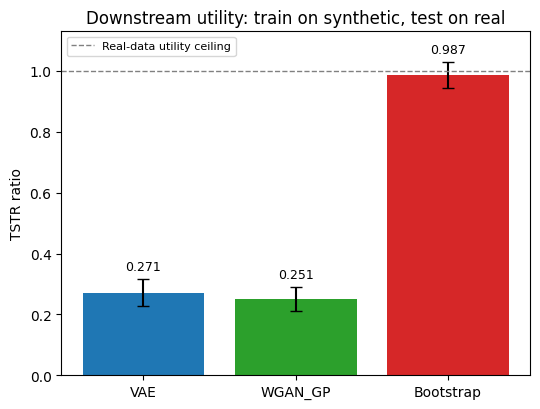

In [ ]:
key = "tstr_ratio"

stats = eval_df.groupby("model")[key].agg(["mean", "std"]).reindex(MODELS)

plt.figure(figsize=(5.5, 4.2))

bars = plt.bar(
    MODELS,
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    color=[COLOURS[mdl] for mdl in MODELS],
)

plt.axhline(1.0, ls="--", c="grey", lw=1, label="Real-data utility ceiling")

for bar, mean, std in zip(bars, stats["mean"], stats["std"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.02,
        f"{mean:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.ylabel("TSTR ratio")
plt.title("Downstream utility: train on synthetic, test on real")
plt.ylim(0, max(1.1, (stats["mean"] + stats["std"]).max() + 0.1))
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "rq1_tstr_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## RQ2 · Privacy / leakage
Two independent privacy axes: **record reproduction** (near-copy) and **membership inference** (MIA, pooled across seeds with a user-level bootstrap CI). DCR/NNDR are degenerate on discretised coordinates — shown for the Limitations note only.

In [ ]:
rec_cols = [c for c in ['near_copy_rate', 'exact_match_rate',
                        'dcr_ratio_train_over_holdout', 'nndr_median'] if c in eval_df.columns]
rec = eval_df.groupby('model')[rec_cols].agg(['mean', 'std']).round(4).reindex(MODELS)
print('RQ2 record-level — near_copy/exact = working; dcr/nndr = degenerate (Limitations):')
display(rec)

RQ2 record-level — near_copy/exact = working; dcr/nndr = degenerate (Limitations):


near_copy_rate         exact_match_rate          \
                    mean     std             mean     std   
model                                                       
VAE               0.0089  0.0014           0.0000  0.0000   
WGAN_GP           0.0099  0.0024           0.0000  0.0000   
Bootstrap         1.0000  0.0000           0.0443  0.0249   

          dcr_ratio_train_over_holdout         nndr_median       
                                  mean     std        mean  std  
model                                                            
VAE                             0.8279  0.0417      1.0000  0.0  
WGAN_GP                         0.8738  0.0289      1.0000  0.0  
Bootstrap                       0.8280  0.0525      0.9996  0.0

In [ ]:
mia_boot, rows = {}, []
for i, mdl in enumerate(MODELS):
    d = pooled[pooled['model'] == mdl]
    pt, ci = cluster_bootstrap(d, seed=1000 + i)
    mia_boot[mdl] = (pt, ci)
    rows.append({'model': mdl, 'n_users': d['user_id'].nunique(),
                 'AUC': fmt(pt, ci, 'auc'), 'Yeom adv': fmt(pt, ci, 'yeom_adv'),
                 'TPR@10%': fmt(pt, ci, 'tpr@10'), 'bal acc': fmt(pt, ci, 'bal_acc')})
mia_tbl = pd.DataFrame(rows).set_index('model').reindex(MODELS)
print('RQ2 pooled MIA — point [95% cluster-bootstrap CI]:'); display(mia_tbl)
mia_tbl.to_csv(OUT_DIR / 'rq2_mia_pooled.csv')

RQ2 pooled MIA — point [95% cluster-bootstrap CI]:


,n_users,AUC,Yeom adv,TPR@10%,bal acc
model,,,,,
VAE,85,"0.497 [0.433, 0.567]","0.050 [0.032, 0.177]","0.114 [0.062, 0.194]","0.515 [0.460, 0.571]"
WGAN_GP,85,"0.503 [0.432, 0.575]","0.070 [0.020, 0.206]","0.103 [0.038, 0.184]","0.474 [0.417, 0.529]"
Bootstrap,85,"0.750 [0.673, 0.823]","0.446 [0.350, 0.577]","0.187 [0.078, 0.386]","0.692 [0.629, 0.757]"


In [ ]:
mia_tbl.T

model,VAE,WGAN_GP,Bootstrap
n_users,85,85,85
AUC,"0.497 [0.433, 0.567]","0.503 [0.432, 0.575]","0.750 [0.673, 0.823]"
Yeom adv,"0.050 [0.032, 0.177]","0.070 [0.020, 0.206]","0.446 [0.350, 0.577]"
TPR@10%,"0.114 [0.062, 0.194]","0.103 [0.038, 0.184]","0.187 [0.078, 0.386]"
bal acc,"0.515 [0.460, 0.571]","0.474 [0.417, 0.529]","0.692 [0.629, 0.757]"


In [ ]:
eval_df.columns

Index(['model', 'seed', 'od_flow_jsd', 'od_flow_js_distance',
       'od_flow_coverage', 'n_real_od_pairs', 'n_synth_od_pairs',
       'origin_cell_js_distance', 'origin_cell_coverage',
       'dest_cell_js_distance', 'dest_cell_coverage', 'hour_js_distance',
       'dow_js_distance', 'corr_mean_abs_diff', 'corr_frobenius',
       'tstr_macro_f1', 'trtr_macro_f1', 'tstr_ratio', 'mean_ks',
       'mean_wasserstein_std', 'mean_std_ratio', 'near_copy_rate',
       'exact_match_rate', 'dcr_train_median', 'dcr_train_p5',
       'dcr_holdout_median', 'dcr_ratio_train_over_holdout', 'nndr_median',
       'nndr_p5', 'mia_accuracy', 'mia_f1', 'mia_auc', 'mia_tpr_at_fpr_1',
       'mia_tpr_at_fpr_5', 'mia_tpr_at_fpr_10'],
      dtype='object')

In [ ]:
# record-level metrics come from per-seed eval_df (mean ± std); MIA from pooled bootstrap ([CI])
rec_keys = [k for k in ['near_copy_rate', 'exact_match_rate',
                        'dcr_ratio_train_over_holdout', 'nndr_median'] if k in eval_df.columns]
rec_stats = eval_df.groupby('model')[rec_keys].agg(['mean', 'std'])
rec_label = {'near_copy_rate': 'near-copy', 'exact_match_rate': 'exact-match',
             'dcr_ratio_train_over_holdout': 'DCR ratio †', 'nndr_median': 'NNDR median †'}

mia_boot, rows = {}, []
for i, mdl in enumerate(MODELS):
    d = pooled[pooled['model'] == mdl]
    pt, ci = cluster_bootstrap(d, seed=1000 + i)
    mia_boot[mdl] = (pt, ci)
    row = {'model': mdl, 'n_users': d['user_id'].nunique(),
           # membership inference — pooled point [95% cluster-bootstrap CI]
           'MIA AUC':  fmt(pt, ci, 'auc'),
           'Yeom adv': fmt(pt, ci, 'yeom_adv'),
           'bal acc':  fmt(pt, ci, 'bal_acc'),
           'TPR@1% ‡': fmt(pt, ci, 'tpr@1'),
           'TPR@5% ‡': fmt(pt, ci, 'tpr@5'),
           'TPR@10%':  fmt(pt, ci, 'tpr@10')}
    # record-level — mean ± std over seeds
    for k in rec_keys:
        mu, sd = rec_stats.loc[mdl, (k, 'mean')], rec_stats.loc[mdl, (k, 'std')]
        row[rec_label[k]] = f'{mu:.3f} ± {sd:.3f}'
    rows.append(row)

priv_tbl = pd.DataFrame(rows).set_index('model').reindex(MODELS)
print('RQ2 privacy — MIA: point [95% CI]; record-level: mean ± std over seeds')
print('  † degenerate on discretised coords (Limitations)   ‡ below ~90 out-user resolution')
display(priv_tbl)
priv_tbl.to_csv(OUT_DIR / 'rq2_privacy_all.csv')

RQ2 privacy — MIA: point [95% CI]; record-level: mean ± std over seeds
  † degenerate on discretised coords (Limitations)   ‡ below ~90 out-user resolution


,n_users,MIA AUC,Yeom adv,bal acc,TPR@1% ‡,TPR@5% ‡,TPR@10%,near-copy,exact-match,DCR ratio †,NNDR median †
model,,,,,,,,,,,
VAE,85,"0.497 [0.433, 0.567]","0.050 [0.032, 0.177]","0.515 [0.460, 0.571]","0.000 [0.000, 0.087]","0.069 [0.039, 0.135]","0.114 [0.062, 0.194]",0.009 ± 0.001,0.000 ± 0.000,0.828 ± 0.042,1.000 ± 0.000
WGAN_GP,85,"0.503 [0.432, 0.575]","0.070 [0.020, 0.206]","0.474 [0.417, 0.529]","0.030 [0.010, 0.070]","0.059 [0.023, 0.116]","0.103 [0.038, 0.184]",0.010 ± 0.002,0.000 ± 0.000,0.874 ± 0.029,1.000 ± 0.000
Bootstrap,85,"0.750 [0.673, 0.823]","0.446 [0.350, 0.577]","0.692 [0.629, 0.757]","0.013 [0.002, 0.074]","0.081 [0.018, 0.237]","0.187 [0.078, 0.386]",1.000 ± 0.000,0.044 ± 0.025,0.828 ± 0.052,1.000 ± 0.000


In [ ]:
priv_tbl.T

model,VAE,WGAN_GP,Bootstrap
n_users,85,85,85
MIA AUC,"0.497 [0.433, 0.567]","0.503 [0.432, 0.575]","0.750 [0.673, 0.823]"
Yeom adv,"0.050 [0.032, 0.177]","0.070 [0.020, 0.206]","0.446 [0.350, 0.577]"
bal acc,"0.515 [0.460, 0.571]","0.474 [0.417, 0.529]","0.692 [0.629, 0.757]"
TPR@1% ‡,"0.000 [0.000, 0.087]","0.030 [0.010, 0.070]","0.013 [0.002, 0.074]"
TPR@5% ‡,"0.069 [0.039, 0.135]","0.059 [0.023, 0.116]","0.081 [0.018, 0.237]"
TPR@10%,"0.114 [0.062, 0.194]","0.103 [0.038, 0.184]","0.187 [0.078, 0.386]"
near-copy,0.009 ± 0.001,0.010 ± 0.002,1.000 ± 0.000
exact-match,0.000 ± 0.000,0.000 ± 0.000,0.044 ± 0.025
DCR ratio †,0.828 ± 0.042,0.874 ± 0.029,0.828 ± 0.052


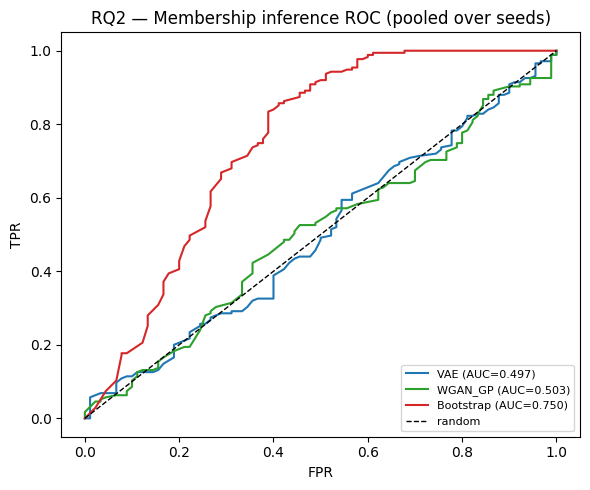

In [ ]:
plt.figure(figsize=(6, 5))
for mdl in MODELS:
    d = pooled[pooled['model'] == mdl]
    fpr, tpr, _ = roc_curve(d['ground_truth'], d['membership_probability'])
    auc = roc_auc_score(d['ground_truth'], d['membership_probability'])
    plt.plot(fpr, tpr, color=COLOURS[mdl], label=f'{mdl} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='random')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(loc='lower right', fontsize=8)
plt.title('Membership inference ROC (pooled over seeds)')
plt.tight_layout(); plt.savefig(OUT_DIR / 'rq2_roc.png', dpi=150, bbox_inches='tight'); plt.show()

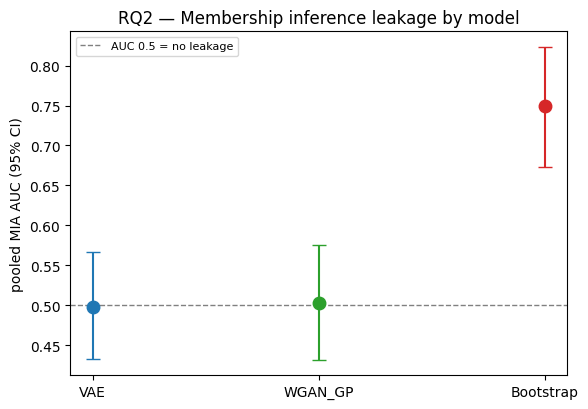

In [ ]:
plt.figure(figsize=(6, 4.2))
for i, mdl in enumerate(MODELS):
    pt, ci = mia_boot[mdl]
    y, (lo, hi) = pt['auc'], ci['auc']
    plt.errorbar(i, y, yerr=[[y - lo], [hi - y]], fmt='o', ms=9, capsize=5, color=COLOURS[mdl])
plt.axhline(0.5, ls='--', c='grey', lw=1, label='AUC 0.5 = no leakage')
plt.xticks(range(len(MODELS)), MODELS)
plt.ylabel('pooled MIA AUC (95% CI)')
plt.title('RQ2 — Membership inference leakage by model')
plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / 'rq2_mia_auc.png', dpi=150, bbox_inches='tight'); plt.show()

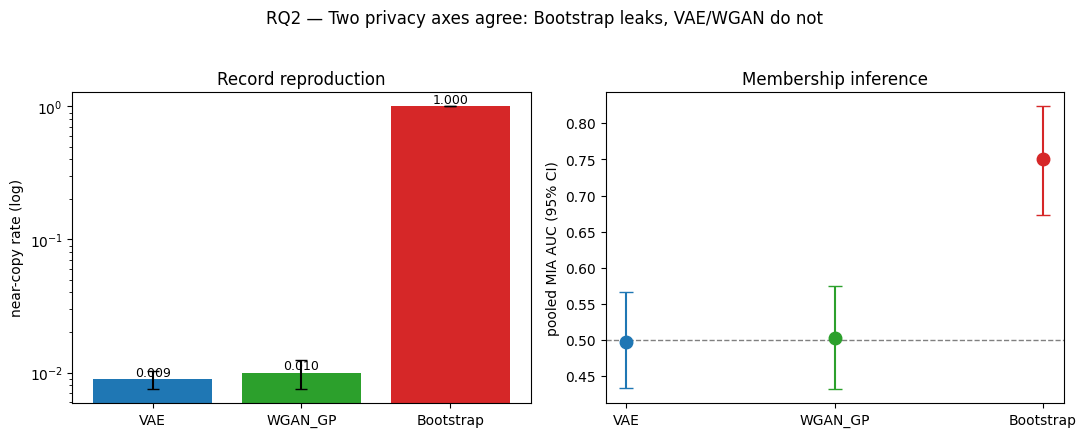

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
nc = eval_df.groupby('model')['near_copy_rate'].agg(['mean', 'std']).reindex(MODELS)
axes[0].bar(MODELS, nc['mean'].clip(lower=1e-3), yerr=nc['std'], capsize=4,
            color=[COLOURS[mdl] for mdl in MODELS])
axes[0].set_yscale('log'); axes[0].set_ylabel('near-copy rate (log)'); axes[0].set_title('Record reproduction')
for mdl, v in zip(MODELS, nc['mean']):
    axes[0].text(mdl, max(v, 1e-3), f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, mdl in enumerate(MODELS):
    pt, ci = mia_boot[mdl]; y, (lo, hi) = pt['auc'], ci['auc']
    axes[1].errorbar(i, y, yerr=[[y - lo], [hi - y]], fmt='o', ms=9, capsize=5, color=COLOURS[mdl])
axes[1].axhline(0.5, ls='--', c='grey', lw=1)
axes[1].set_xticks(range(len(MODELS))); axes[1].set_xticklabels(MODELS)
axes[1].set_ylabel('pooled MIA AUC (95% CI)'); axes[1].set_title('Membership inference')
plt.suptitle('RQ2 — Two privacy axes agree: Bootstrap leaks, VAE/WGAN do not', y=1.03)
plt.tight_layout(); plt.savefig(OUT_DIR / 'rq2_two_axes.png', dpi=150, bbox_inches='tight'); plt.show()


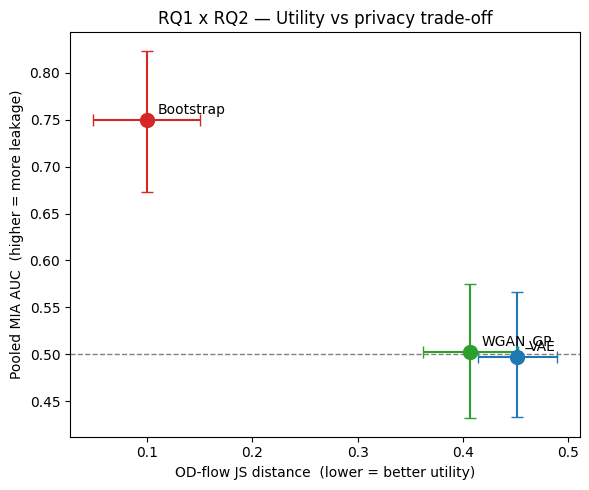

In [ ]:
u = eval_df.groupby('model')['od_flow_jsd'].agg(['mean', 'std']).reindex(MODELS)
plt.figure(figsize=(6, 5))
for mdl in MODELS:
    pt, ci = mia_boot[mdl]
    x, xs = u.loc[mdl, 'mean'], u.loc[mdl, 'std']; y, (lo, hi) = pt['auc'], ci['auc']
    plt.errorbar(x, y, xerr=xs, yerr=[[y - lo], [hi - y]], fmt='o', ms=10, capsize=4, color=COLOURS[mdl])
    plt.annotate(mdl, (x, y), textcoords='offset points', xytext=(8, 4))
plt.axhline(0.5, ls='--', c='grey', lw=1)
plt.xlabel('OD-flow JS distance  (lower = better utility)')
plt.ylabel('Pooled MIA AUC  (higher = more leakage)')
plt.title('RQ1 x RQ2 — Utility vs privacy trade-off')
plt.tight_layout(); plt.savefig(OUT_DIR / 'tradeoff.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
privacy_metric_map = {
    'near_copy_rate': 'Near-copy rate',
    'exact_match_rate': 'Exact-match rate',
    'dcr_ratio_train_over_holdout': 'DCR ratio',
    'nndr_median': 'NNDR median',
    'mia_auc': 'MIA AUC',
    'mia_yeom_adv': 'Yeom advantage',
    'mia_balanced_accuracy': 'Balanced accuracy',
    'mia_tpr_at_fpr_10': 'TPR @ FPR=10%',
    'mia_tpr_at_fpr_5': 'TPR @ FPR=5%',
    'mia_tpr_at_fpr_1': 'TPR @ FPR=1%',
    'mia_accuracy': 'MIA accuracy',
    'mia_f1': 'MIA F1'
}

rows = []

for model in MODELS:
    row = {'Model': model}

    for col, label in privacy_metric_map.items():

        if col not in eval_df.columns:
            row[label] = 'N/A'
            continue

        mean = eval_df.loc[
            eval_df['model'] == model,
            col
        ].mean()

        std = eval_df.loc[
            eval_df['model'] == model,
            col
        ].std()

        row[label] = f'{mean:.3f} ± {std:.3f}'

    rows.append(row)

privacy_tbl = pd.DataFrame(rows).set_index('Model')

display(privacy_tbl.T)

# optional
# privacy_tbl.to_csv(OUT_DIR / 'rq2_privacy_table.csv')


Model,VAE,WGAN_GP,Bootstrap
Near-copy rate,0.009 ± 0.001,0.010 ± 0.002,1.000 ± 0.000
Exact-match rate,0.000 ± 0.000,0.000 ± 0.000,0.044 ± 0.025
DCR ratio,0.828 ± 0.042,0.874 ± 0.029,0.828 ± 0.052
NNDR median,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
MIA AUC,0.505 ± 0.037,0.502 ± 0.065,0.756 ± 0.128
Yeom advantage,N/A,N/A,N/A
Balanced accuracy,N/A,N/A,N/A
TPR @ FPR=10%,0.080 ± 0.071,0.080 ± 0.051,0.267 ± 0.198
TPR @ FPR=5%,0.034 ± 0.030,0.072 ± 0.047,0.116 ± 0.176
TPR @ FPR=1%,0.030 ± 0.022,0.056 ± 0.046,0.087 ± 0.178


## RQ3 · Activity-group differential leakage
Do higher-activity users leak more? Per-group MIA is **pooled across seeds within group** (per-seed n_out is too small), with user-level bootstrap CIs. Bootstrap is the control: if even maximal leakage is flat across groups, a null for the real models is genuine, not just an underpowered attack.

In [ ]:
# RQ3 privacy by activity group
# record-level metrics: mean ± std over seeds within each activity group
# MIA metrics: pooled within activity group + user-level bootstrap CI

# -----------------------------
# Build per-group eval table
# -----------------------------
rows = []

for r in json.loads(Path(EVAL_LOG).read_text()):
    model = r['model'].replace('__eval', '')
    seed = r['seed']
    by_group = r['metrics'].get('by_activity_group', {})

    for g, vals in by_group.items():
        rows.append({
            'model': model,
            'seed': seed,
            'group': str(g).replace('–', '-').strip(),
            **vals
        })

group_eval = pd.DataFrame(rows)

# -----------------------------
# Record-level metrics
# -----------------------------
rec_keys = [
    k for k in [
        'priv_near_copy_rate',
        'priv_exact_match_rate',
        'priv_dcr_ratio_train_over_holdout',
        'priv_nndr_median'
    ]
    if k in group_eval.columns
]

rec_stats = group_eval.groupby(['model', 'group'])[rec_keys].agg(['mean', 'std'])

rec_label = {
    'priv_near_copy_rate': 'near-copy',
    'priv_exact_match_rate': 'exact-match',
    'priv_dcr_ratio_train_over_holdout': 'DCR ratio †',
    'priv_nndr_median': 'NNDR median †'
}

# -----------------------------
# Combined RQ3 table
# -----------------------------
mia_boot_by_group, rows = {}, []

for i, mdl in enumerate(MODELS):
    for j, grp in enumerate(GROUP_ORDER):

        d = pooled[
            (pooled['model'] == mdl) &
            (pooled['activity_group'].astype(str).str.replace('–', '-', regex=False).str.strip() == grp)
        ]

        row = {
            'model': mdl,
            'activity_group': grp,
        }

        if d.empty or d['ground_truth'].nunique() < 2:
            row.update({
                'n_users': 0,
                'MIA AUC': 'N/A',
                'Yeom adv': 'N/A',
                'bal acc': 'N/A',
                'TPR@1% ‡': 'N/A',
                'TPR@5% ‡': 'N/A',
                'TPR@10%': 'N/A',
            })
        else:
            pt, ci = cluster_bootstrap(d, seed=2000 + i * 10 + j)
            mia_boot_by_group[(mdl, grp)] = (pt, ci)

            row.update({
                'n_users': d['user_id'].nunique(),
                'MIA AUC':  fmt(pt, ci, 'auc'),
                'Yeom adv': fmt(pt, ci, 'yeom_adv'),
                'bal acc':  fmt(pt, ci, 'bal_acc'),
                'TPR@1% ‡': fmt(pt, ci, 'tpr@1'),
                'TPR@5% ‡': fmt(pt, ci, 'tpr@5'),
                'TPR@10%':  fmt(pt, ci, 'tpr@10'),
            })

        # record-level metrics: mean ± std over seeds
        for k in rec_keys:
            if (mdl, grp) in rec_stats.index:
                mu = rec_stats.loc[(mdl, grp), (k, 'mean')]
                sd = rec_stats.loc[(mdl, grp), (k, 'std')]
                row[rec_label[k]] = f'{mu:.3f} ± {sd:.3f}'
            else:
                row[rec_label[k]] = 'N/A'

        rows.append(row)

rq3_priv_tbl = (
    pd.DataFrame(rows)
    .set_index(['model', 'activity_group'])
    .reindex(pd.MultiIndex.from_product([MODELS, GROUP_ORDER],
                                        names=['model', 'activity_group']))
)

print('RQ3 privacy by activity group — MIA: point [95% CI]; record-level: mean ± std over seeds')
print('  † degenerate on discretised coords (Limitations)   ‡ below ~90 out-user resolution')
display(rq3_priv_tbl)

rq3_priv_tbl.to_csv(OUT_DIR / 'rq3_privacy_by_activity_group.csv')

RQ3 privacy by activity group — MIA: point [95% CI]; record-level: mean ± std over seeds
  † degenerate on discretised coords (Limitations)   ‡ below ~90 out-user resolution


n_users               MIA AUC              Yeom adv  \
model     activity_group                                                        
VAE       10-20                28  0.580 [0.440, 0.716]  0.245 [0.092, 0.456]   
          21-63                29  0.530 [0.460, 0.610]  0.163 [0.109, 0.315]   
          64+                  28  0.392 [0.273, 0.517]  0.068 [0.000, 0.210]   
WGAN_GP   10-20                28  0.578 [0.468, 0.692]  0.211 [0.101, 0.429]   
          21-63                29  0.490 [0.382, 0.598]  0.112 [0.050, 0.304]   
          64+                  28  0.460 [0.320, 0.612]  0.093 [0.016, 0.362]   
Bootstrap 10-20                28  0.729 [0.618, 0.858]  0.396 [0.267, 0.650]   
          21-63                29  0.770 [0.652, 0.874]  0.482 [0.338, 0.683]   
          64+                  28  0.746 [0.582, 0.895]  0.516 [0.346, 0.759]   

                                       bal acc              TPR@1% ‡  \
model     activity_group                                               
VAE       10-20           0.623 [0.523, 0.722]  0.102 [0.031, 0.257]   
          21-63           0.491 [0.418, 0.580]  0.158 [0.064, 0.295]   
          64+             0.431 [0.339, 0.528]  0.000 [0.000, 0.158]   
WGAN_GP   10-20           0.514 [0.408, 0.618]  0.034 [0.000, 0.179]   
          21-63           0.468 [0.386, 0.549]  0.035 [0.000, 0.200]   
          64+             0.440 [0.339, 0.537]  0.039 [0.002, 0.111]   
Bootstrap 10-20           0.675 [0.568, 0.808]  0.010 [0.000, 0.245]   
          21-63           0.667 [0.562, 0.786]  0.011 [0.000, 0.320]   
          64+             0.733 [0.628, 0.844]  0.030 [0.003, 0.253]   

                                      TPR@5% ‡               TPR@10%  \
model     activity_group                                               
VAE       10-20           0.119 [0.034, 0.316]  0.186 [0.057, 0.379]   
          21-63           0.197 [0.078, 0.328]  0.263 [0.113, 0.362]   
          64+             0.102 [0.000, 0.182]  0.102 [0.000, 0.193]   
WGAN_GP   10-20           0.042 [0.000, 0.286]  0.220 [0.024, 0.400]   
          21-63           0.070 [0.000, 0.271]  0.193 [0.029, 0.327]   
          64+             0.059 [0.011, 0.148]  0.068 [0.016, 0.196]   
Bootstrap 10-20           0.076 [0.000, 0.375]  0.237 [0.019, 0.586]   
          21-63           0.114 [0.000, 0.500]  0.316 [0.036, 0.569]   
          64+             0.081 [0.017, 0.347]  0.237 [0.038, 0.623]   

                              near-copy    exact-match    DCR ratio †  \
model     activity_group                                                
VAE       10-20           0.004 ± 0.001  0.000 ± 0.000  0.730 ± 0.035   
          21-63           0.005 ± 0.001  0.000 ± 0.000  0.682 ± 0.057   
          64+             0.008 ± 0.001  0.000 ± 0.000  0.802 ± 0.061   
WGAN_GP   10-20           0.006 ± 0.002  0.000 ± 0.000  0.725 ± 0.075   
          21-63           0.007 ± 0.002  0.000 ± 0.000  0.681 ± 0.060   
          64+             0.010 ± 0.002  0.000 ± 0.000  0.854 ± 0.045   
Bootstrap 10-20           0.483 ± 0.040  0.028 ± 0.012  0.361 ± 0.494   
          21-63           0.613 ± 0.011  0.039 ± 0.026  0.000 ± 0.000   
          64+             0.935 ± 0.025  0.043 ± 0.025  0.655 ± 0.191   

                          NNDR median †  
model     activity_group                 
VAE       10-20           0.946 ± 0.011  
          21-63           0.985 ± 0.010  
          64+             1.000 ± 0.000  
WGAN_GP   10-20           0.975 ± 0.020  
          21-63           0.998 ± 0.005  
          64+             1.000 ± 0.000  
Bootstrap 10-20           0.999 ± 0.000  
          21-63           0.999 ± 0.000  
          64+             1.000 ± 0.000

In [ ]:
rq3_priv_tbl.T

model                            VAE                        \
activity_group                 10-20                 21-63   
n_users                           28                    29   
MIA AUC         0.580 [0.440, 0.716]  0.530 [0.460, 0.610]   
Yeom adv        0.245 [0.092, 0.456]  0.163 [0.109, 0.315]   
bal acc         0.623 [0.523, 0.722]  0.491 [0.418, 0.580]   
TPR@1% ‡        0.102 [0.031, 0.257]  0.158 [0.064, 0.295]   
TPR@5% ‡        0.119 [0.034, 0.316]  0.197 [0.078, 0.328]   
TPR@10%         0.186 [0.057, 0.379]  0.263 [0.113, 0.362]   
near-copy              0.004 ± 0.001         0.005 ± 0.001   
exact-match            0.000 ± 0.000         0.000 ± 0.000   
DCR ratio †            0.730 ± 0.035         0.682 ± 0.057   
NNDR median †          0.946 ± 0.011         0.985 ± 0.010   

model                                              WGAN_GP  \
activity_group                   64+                 10-20   
n_users                           28                    28   
MIA AUC         0.392 [0.273, 0.517]  0.578 [0.468, 0.692]   
Yeom adv        0.068 [0.000, 0.210]  0.211 [0.101, 0.429]   
bal acc         0.431 [0.339, 0.528]  0.514 [0.408, 0.618]   
TPR@1% ‡        0.000 [0.000, 0.158]  0.034 [0.000, 0.179]   
TPR@5% ‡        0.102 [0.000, 0.182]  0.042 [0.000, 0.286]   
TPR@10%         0.102 [0.000, 0.193]  0.220 [0.024, 0.400]   
near-copy              0.008 ± 0.001         0.006 ± 0.002   
exact-match            0.000 ± 0.000         0.000 ± 0.000   
DCR ratio †            0.802 ± 0.061         0.725 ± 0.075   
NNDR median †          1.000 ± 0.000         0.975 ± 0.020   

model                                                       \
activity_group                 21-63                   64+   
n_users                           29                    28   
MIA AUC         0.490 [0.382, 0.598]  0.460 [0.320, 0.612]   
Yeom adv        0.112 [0.050, 0.304]  0.093 [0.016, 0.362]   
bal acc         0.468 [0.386, 0.549]  0.440 [0.339, 0.537]   
TPR@1% ‡        0.035 [0.000, 0.200]  0.039 [0.002, 0.111]   
TPR@5% ‡        0.070 [0.000, 0.271]  0.059 [0.011, 0.148]   
TPR@10%         0.193 [0.029, 0.327]  0.068 [0.016, 0.196]   
near-copy              0.007 ± 0.002         0.010 ± 0.002   
exact-match            0.000 ± 0.000         0.000 ± 0.000   
DCR ratio †            0.681 ± 0.060         0.854 ± 0.045   
NNDR median †          0.998 ± 0.005         1.000 ± 0.000   

model                      Bootstrap                        \
activity_group                 10-20                 21-63   
n_users                           28                    29   
MIA AUC         0.729 [0.618, 0.858]  0.770 [0.652, 0.874]   
Yeom adv        0.396 [0.267, 0.650]  0.482 [0.338, 0.683]   
bal acc         0.675 [0.568, 0.808]  0.667 [0.562, 0.786]   
TPR@1% ‡        0.010 [0.000, 0.245]  0.011 [0.000, 0.320]   
TPR@5% ‡        0.076 [0.000, 0.375]  0.114 [0.000, 0.500]   
TPR@10%         0.237 [0.019, 0.586]  0.316 [0.036, 0.569]   
near-copy              0.483 ± 0.040         0.613 ± 0.011   
exact-match            0.028 ± 0.012         0.039 ± 0.026   
DCR ratio †            0.361 ± 0.494         0.000 ± 0.000   
NNDR median †          0.999 ± 0.000         0.999 ± 0.000   

model                                 
activity_group                   64+  
n_users                           28  
MIA AUC         0.746 [0.582, 0.895]  
Yeom adv        0.516 [0.346, 0.759]  
bal acc         0.733 [0.628, 0.844]  
TPR@1% ‡        0.030 [0.003, 0.253]  
TPR@5% ‡        0.081 [0.017, 0.347]  
TPR@10%         0.237 [0.038, 0.623]  
near-copy              0.935 ± 0.025  
exact-match            0.043 ± 0.025  
DCR ratio †            0.655 ± 0.191  
NNDR median †          1.000 ± 0.000

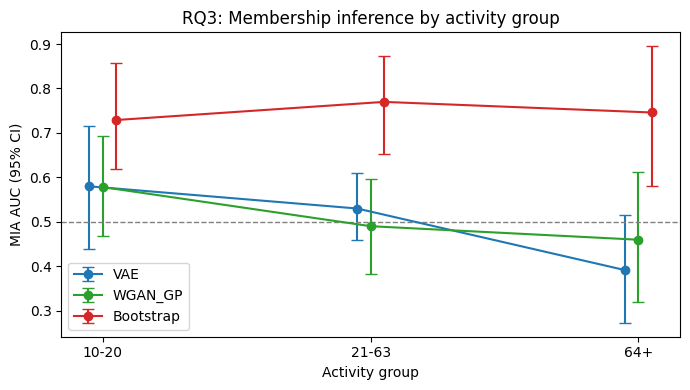

In [ ]:
offsets = {
    'VAE': -0.05,
    'WGAN_GP': 0.0,
    'Bootstrap': +0.05
}

x_base = np.arange(len(GROUP_ORDER))

plt.figure(figsize=(7,4))

for mdl in MODELS:

    xs, ys = [], []
    yerr_lo, yerr_hi = [], []

    for j, grp in enumerate(GROUP_ORDER):

        pt, ci = mia_boot_by_group[(mdl, grp)]

        y = pt['auc']
        lo, hi = ci['auc']

        xs.append(x_base[j] + offsets[mdl])
        ys.append(y)

        yerr_lo.append(y - lo)
        yerr_hi.append(hi - y)

    plt.errorbar(
        xs,
        ys,
        yerr=[yerr_lo, yerr_hi],
        fmt='o-',
        capsize=4,
        label=mdl,
        color=COLOURS[mdl]
    )

plt.axhline(0.5, ls='--', c='grey', lw=1)

plt.xticks(x_base, GROUP_ORDER)
plt.xlabel('Activity group')
plt.ylabel('MIA AUC (95% CI)')
plt.title('RQ3: Membership inference by activity group')
plt.legend()

plt.tight_layout()
plt.show()

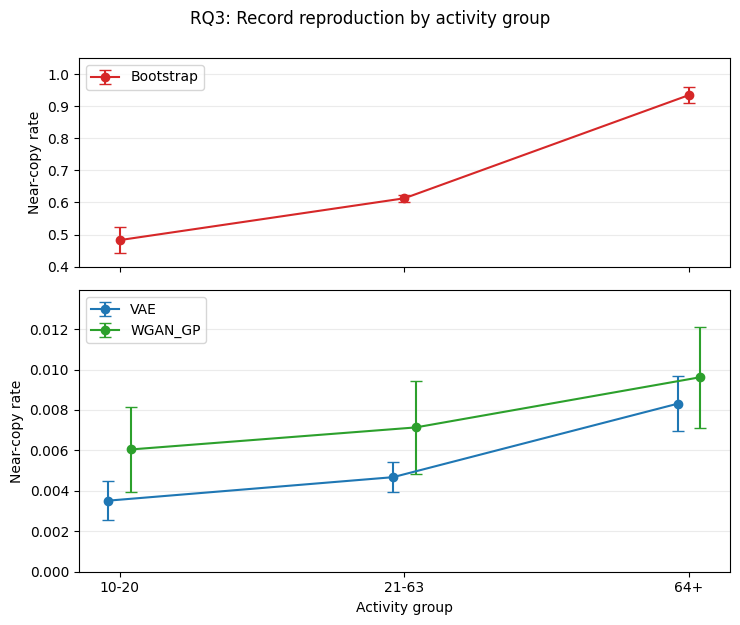

In [ ]:
# RQ3 near-copy rate by activity group
# Top: Bootstrap only
# Bottom: deep generative models only
# Error bars = std over seeds

x_base = np.arange(len(GROUP_ORDER))

fig, axes = plt.subplots(
    2, 1,
    figsize=(7.5, 6.2),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1.35]}
)

# -------------------------
# Top panel: Bootstrap only
# -------------------------
ax = axes[0]
mdl = 'Bootstrap'

means, stds = [], []
for grp in GROUP_ORDER:
    d = group_eval[
        (group_eval['model'] == mdl) &
        (group_eval['group'] == grp)
    ]
    means.append(d['priv_near_copy_rate'].mean())
    stds.append(d['priv_near_copy_rate'].std())

ax.errorbar(
    x_base,
    means,
    yerr=stds,
    fmt='o-',
    capsize=4,
    color=COLOURS[mdl],
    label=mdl
)

ax.set_ylabel('Near-copy rate')
#ax.set_title('Bootstrap control')
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.25)

# give a little breathing room around the error bars
ymax = max(np.array(means) + np.array(stds))
ax.set_ylim(0.4, min(1.05, ymax * 1.15))

# -------------------------
# Bottom panel: VAE + WGAN
# -------------------------
ax = axes[1]

offsets = {
    'VAE': -0.04,
    'WGAN_GP': +0.04
}

for mdl in ['VAE', 'WGAN_GP']:

    means, stds, xs = [], [], []

    for j, grp in enumerate(GROUP_ORDER):
        d = group_eval[
            (group_eval['model'] == mdl) &
            (group_eval['group'] == grp)
        ]

        xs.append(x_base[j] + offsets[mdl])
        means.append(d['priv_near_copy_rate'].mean())
        stds.append(d['priv_near_copy_rate'].std())

    ax.errorbar(
        xs,
        means,
        yerr=stds,
        fmt='o-',
        capsize=4,
        color=COLOURS[mdl],
        label=mdl
    )

ax.set_xticks(x_base)
ax.set_xticklabels(GROUP_ORDER)
ax.set_xlabel('Activity group')
ax.set_ylabel('Near-copy rate')
#ax.set_title('Deep generative models')
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.25)

# zoom y-axis to deep models only
deep_vals = []
for mdl in ['VAE', 'WGAN_GP']:
    for grp in GROUP_ORDER:
        d = group_eval[
            (group_eval['model'] == mdl) &
            (group_eval['group'] == grp)
        ]
        deep_vals.append(d['priv_near_copy_rate'].mean() + d['priv_near_copy_rate'].std())

ax.set_ylim(0, max(deep_vals) * 1.15)

plt.suptitle('RQ3: Record reproduction by activity group', y=1.00)
plt.tight_layout()

plt.savefig(
    OUT_DIR / 'rq3_near_copy_by_activity_group_split.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Interpretation anchors
- **Bootstrap is the control, not a competitor** — it sets the leakage upper bound and the fidelity ceiling. A chance-level MIA on VAE/WGAN reads as *genuine* low leakage because Bootstrap fires; a flat-across-groups Bootstrap means the RQ3 null is real, not underpowered.
- **Reference points:** MIA AUC 0.5 · near_copy_rate ≈ 0 · std_ratio ≈ 1 · DCR ratio ≈ 1.
- **Limitations (degenerate / underpowered on this representation):** `dcr_ratio`, `nndr` (centroid discretisation); `mean_ks` (spiky marginals); `tpr@1%`/`tpr@5%` (below ~90 out-user resolution); per-group n (RQ3 power); `tstr` (deferred). Drop `mia_accuracy` / `mia_f1` (imbalanced eval).